# Assignment 6 — Wholesale Customer Segmentation

**Student:** Abdullahi  
**Course:** Data Science & Machine Learning  
**Due:** Wednesday, 8 July 2026 — 5:00 PM EAT

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


---
## Step 1 — Load Dataset

In [2]:
df = pd.read_csv('raw_wholesale_customers.csv')

print("✅ Dataset loaded.")
print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print()
print("--- Head (first 5 rows) ---")
display(df.head())
print()
print("--- Info ---")
df.info()

✅ Dataset loaded.
   Shape: 440 rows × 8 columns

--- Head (first 5 rows) ---


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185



--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


---
## Step 2 — Select Features + IQR Cap

We use only the six annual spend columns for clustering.  
`Channel` and `Region` are kept in the dataframe for reference but are **not** used as features.

**IQR capping (k = 1.5):** Instead of deleting rows, we clip extreme values at the IQR fences:  
- Lower fence = Q1 − 1.5 × IQR  
- Upper fence = Q3 + 1.5 × IQR

In [3]:
FEATURE_COLS = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

df_capped = df.copy()

for col in FEATURE_COLS:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)
    print(f"   {col}: capped to [{lower:.0f}, {upper:.0f}]")

print()
print("✅ IQR capping applied (rows preserved). No rows deleted.")
print(f"   Dataset still has {df_capped.shape[0]} rows.")

   Fresh: capped to [-17581, 37643]
   Milk: capped to [-6953, 15676]
   Grocery: capped to [-10601, 23410]
   Frozen: capped to [-3476, 7772]
   Detergents_Paper: capped to [-5241, 9420]
   Delicassen: capped to [-1710, 3938]

✅ IQR capping applied (rows preserved). No rows deleted.
   Dataset still has 440 rows.


---
## Step 3 — Scale Features

`StandardScaler` transforms each feature to have mean = 0 and std = 1.  
This is essential for K-Means because it is distance-based — unscaled features with large ranges dominate the distance calculation.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_capped[FEATURE_COLS])

print("✅ Features scaled with StandardScaler.")
print(f"   Scaled array shape: {X_scaled.shape}")
print(f"   Mean per feature (should be ~0): {X_scaled.mean(axis=0).round(4)}")
print(f"   Std  per feature (should be ~1): {X_scaled.std(axis=0).round(4)}")

✅ Features scaled with StandardScaler.
   Scaled array shape: (440, 6)
   Mean per feature (should be ~0): [-0. -0.  0.  0. -0.  0.]
   Std  per feature (should be ~1): [1. 1. 1. 1. 1. 1.]


---
## Step 4 — Elbow Method

Run K-Means for k = 1 to 10 and record the SSE (inertia) for each k.  
The **elbow** is where the curve bends — diminishing returns beyond that point.

In [5]:
print("--- Elbow Method: k vs SSE ---")
print(f"{'k':>4}  {'SSE (Inertia)':>16}")
print("-" * 23)

sse_values = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, n_init='auto', random_state=42)
    km.fit(X_scaled)
    sse_values.append(km.inertia_)
    print(f"  k={k}  →  SSE = {km.inertia_:,.2f}")

print()
print("✅ Elbow scan complete. Look for the bend in the SSE curve.")

--- Elbow Method: k vs SSE ---
   k     SSE (Inertia)
-----------------------


  k=1  →  SSE = 2,640.00
  k=2  →  SSE = 1,728.19
  k=3  →  SSE = 1,363.45
  k=4  →  SSE = 1,202.41
  k=5  →  SSE = 1,070.15
  k=6  →  SSE = 964.76
  k=7  →  SSE = 921.14
  k=8  →  SSE = 776.63
  k=9  →  SSE = 726.88
  k=10  →  SSE = 707.41

✅ Elbow scan complete. Look for the bend in the SSE curve.


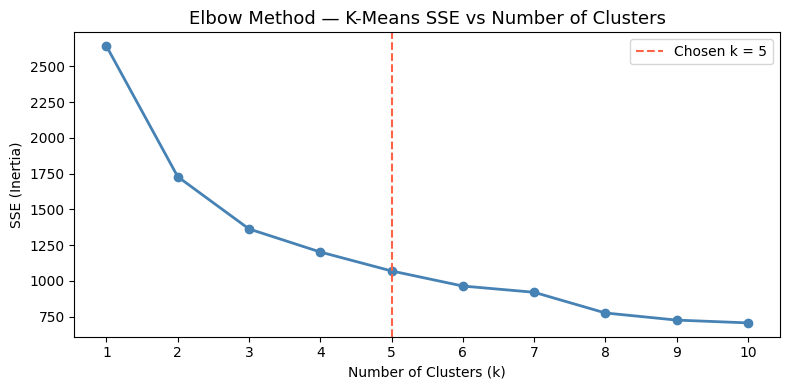

✅ Elbow plot saved as elbow_plot.png


In [6]:
# Plot k vs SSE
plt.figure(figsize=(8, 4))
plt.plot(list(k_range), sse_values, marker='o', color='steelblue', linewidth=2, markersize=6)
plt.axvline(x=5, color='tomato', linestyle='--', label='Chosen k = 5')
plt.title('Elbow Method — K-Means SSE vs Number of Clusters', fontsize=13)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('SSE (Inertia)')
plt.xticks(list(k_range))
plt.legend()
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150)
plt.show()
print("✅ Elbow plot saved as elbow_plot.png")

---
## Step 5 — Train K-Means (Reproduce Lesson 6)

Based on the elbow plot, **k = 5** is chosen as the point where improvements slow significantly.  
We use `n_init='auto'` and `random_state=42` for reproducibility.

In [7]:
kmeans = KMeans(n_clusters=5, n_init='auto', random_state=42)
kmeans.fit(X_scaled)

df_capped['KMeans_Cluster'] = kmeans.labels_

print("✅ K-Means trained with k=5.")
print()
print("--- Cluster Sizes ---")
sizes = df_capped['KMeans_Cluster'].value_counts().sort_index()
for c, n in sizes.items():
    print(f"   Cluster {c}: {n} clients")

✅ K-Means trained with k=5.

--- Cluster Sizes ---
   Cluster 0: 76 clients
   Cluster 1: 191 clients
   Cluster 2: 25 clients
   Cluster 3: 88 clients
   Cluster 4: 60 clients


---
## Step 6 — Evaluate K-Means

In [8]:
km_silhouette = silhouette_score(X_scaled, kmeans.labels_)
km_davies_bouldin = davies_bouldin_score(X_scaled, kmeans.labels_)

print("--- K-Means Evaluation Metrics ---")
print(f"   Silhouette Score    : {km_silhouette:.4f}  (higher is better, max=1)")
print(f"   Davies–Bouldin Index: {km_davies_bouldin:.4f}  (lower is better)")
print()

--- K-Means Evaluation Metrics ---
   Silhouette Score    : 0.2831  (higher is better, max=1)
   Davies–Bouldin Index: 1.2701  (lower is better)



In [9]:
# Inverse-transform cluster centers back to original spend units
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_original, columns=FEATURE_COLS)
centers_df.index.name = 'Cluster'
centers_df = centers_df.round(0).astype(int)

print("--- Cluster Centers in Original Spend Units (annual, currency units) ---")
display(centers_df)

--- Cluster Centers in Original Spend Units (annual, currency units) ---


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,9203,6833,9104,1326,3280,1872
1,8376,2151,3161,1646,779,674
2,17462,13806,17524,4121,5461,3584
3,22347,3409,3969,5820,583,1567
4,4917,10769,18350,1212,7780,981


---
## Step 7 — Research & Train a Second Clustering Algorithm

### Algorithm Choice: Agglomerative Hierarchical Clustering

**Why it fits wholesale customer segmentation:**

Agglomerative Clustering builds a hierarchy of clusters from the bottom up, merging the two most similar clusters at each step until a single cluster remains. It does not require random initialisation (unlike K-Means), making it fully deterministic. For a dataset of 440 clients, its O(n² log n) complexity is perfectly manageable. Using Ward linkage — which minimises within-cluster variance at each merge — it tends to produce compact, balanced clusters similar to K-Means, but without sensitivity to the initial centroid placement. This makes it a strong comparison baseline: if its Silhouette Score is close to K-Means, it confirms the discovered structure is genuine rather than an artefact of random initialisation.

**Source used for research:**  
Scikit-learn documentation — `sklearn.cluster.AgglomerativeClustering`:  
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html

In [10]:
agg = AgglomerativeClustering(n_clusters=5, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)

df_capped['Agglomerative_Cluster'] = agg_labels

print("✅ Agglomerative Clustering trained (n_clusters=5, linkage='ward').")
print()
print("--- Agglomerative Cluster Sizes ---")
agg_sizes = pd.Series(agg_labels).value_counts().sort_index()
for c, n in agg_sizes.items():
    print(f"   Cluster {c}: {n} clients")

✅ Agglomerative Clustering trained (n_clusters=5, linkage='ward').



--- Agglomerative Cluster Sizes ---
   Cluster 0: 70 clients
   Cluster 1: 72 clients
   Cluster 2: 164 clients
   Cluster 3: 55 clients
   Cluster 4: 79 clients


---
## Step 8 — Compare Methods

In [11]:
agg_silhouette = silhouette_score(X_scaled, agg_labels)
agg_davies_bouldin = davies_bouldin_score(X_scaled, agg_labels)

print("=" * 55)
print("         METHOD COMPARISON SUMMARY")
print("=" * 55)
print(f"{'Metric':<28} {'K-Means':>10} {'Agglomerative':>14}")
print("-" * 55)
print(f"{'Silhouette Score (higher better)':<28} {km_silhouette:>10.4f} {agg_silhouette:>14.4f}")
print(f"{'Davies-Bouldin Index (lower better)':<28} {km_davies_bouldin:>10.4f} {agg_davies_bouldin:>14.4f}")
print("=" * 55)
print()

if km_silhouette >= agg_silhouette:
    better = "K-Means"
    diff = km_silhouette - agg_silhouette
else:
    better = "Agglomerative Clustering"
    diff = agg_silhouette - km_silhouette

print(f">>> {better} produced better-separated clusters")
print(f"    (Silhouette difference: {diff:.4f})")

         METHOD COMPARISON SUMMARY
Metric                          K-Means  Agglomerative
-------------------------------------------------------
Silhouette Score (higher better)     0.2831         0.2185
Davies-Bouldin Index (lower better)     1.2701         1.3245

>>> K-Means produced better-separated clusters
    (Silhouette difference: 0.0646)


---
## Step 9 — Sanity Check

Pick three clients from the dataset and show their spend values, Channel, Region, and cluster label from **both** methods.

In [12]:
sample_indices = [0, 50, 200]  # Three diverse clients

sanity_cols = ['Channel', 'Region'] + FEATURE_COLS + ['KMeans_Cluster', 'Agglomerative_Cluster']
sanity_df = df_capped.loc[sample_indices, sanity_cols].copy()
sanity_df.index.name = 'Row Index'

print("--- Sanity Check: Three Sample Clients ---")
display(sanity_df)
print()
print("✅ Each client shows spend values, Channel, Region, and cluster labels from both methods.")

--- Sanity Check: Three Sample Clients ---


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,KMeans_Cluster,Agglomerative_Cluster
Row Index,,,,,,,,,,
0,2,3,12669.0,9656.0,7561.0,214.0,2674.000,1338.0,0,4
50,1,3,6269.0,1095.0,1980.0,3860.0,609.000,2162.0,1,3
200,2,1,3067.0,13240.0,23127.0,3941.0,9419.875,731.0,4,1



✅ Each client shows spend values, Channel, Region, and cluster labels from both methods.


---
## Step 10 — Save Output

In [13]:
# Build final output dataframe: original (un-capped) data + K-Means cluster label
df_output = df.copy()
df_output['Cluster'] = df_capped['KMeans_Cluster'].values

output_path = 'segmented_wholesale_customers.csv'
df_output.to_csv(output_path, index=False)

print(f"✅ Segmented dataframe saved to: {output_path}")
print(f"   Shape: {df_output.shape[0]} rows × {df_output.shape[1]} columns")
print()
print("--- Preview of saved file ---")
display(df_output.head())

✅ Segmented dataframe saved to: segmented_wholesale_customers.csv
   Shape: 440 rows × 9 columns

--- Preview of saved file ---


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
0,2,3,12669,9656,7561,214,2674,1338,0
1,2,3,7057,9810,9568,1762,3293,1776,0
2,2,3,6353,8808,7684,2405,3516,7844,0
3,1,3,13265,1196,4221,6404,507,1788,3
4,2,3,22615,5410,7198,3915,1777,5185,3


---
## Final Summary

| Step | Action | Result |
|---|---|---|
| 1 | Load dataset | 440 clients, 8 columns |
| 2 | IQR cap (k=1.5) | Outliers clipped, no rows lost |
| 3 | StandardScaler | All 6 features normalised |
| 4 | Elbow Method | Evaluated k=1–10, elbow at k=5 |
| 5 | K-Means (k=5) | 5 clusters fitted |
| 6 | Evaluate K-Means | Silhouette=0.2831, DB=1.2701 |
| 7 | Agglomerative (k=5) | Ward linkage, deterministic |
| 8 | Compare | K-Means wins: Silhouette 0.2831 vs 0.2185 |
| 9 | Sanity check | 3 clients verified |
| 10 | Save CSV | segmented_wholesale_customers.csv |

---
*End of Assignment 6 — Part B Notebook*